## Imports

In [3]:
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import matplotlib.pyplot as plt
import numpy as np
import os 
from datetime import datetime
import pandas as pd

In [4]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## Set up

In [5]:
# Path to load the data

# Amélie
link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# Amélie PC
# link = r"E:\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"E:\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

In [8]:
def run(link, df_link, File, id = 'pred_vdist', mode = 'random', load = True, pretrained_folder = None):

    
    # Set the parameters
    N_episodes = 26 # 26 
    ep_len     = 5

    buffer_size = 6000
    batch_size = 32

    # --- Create maps --- 

    # Map parameters
    x_size = 20
    y_size = 30


    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File, load = load)
    Map.initialize_better_importance_map(id)

    print(Map.importance_map.shape)

    # ----- Create a fleet -----
    
    drone_init_pos = [[5,7], [3,26], [10, 3], [10,26]]

    state_shape    = [ep_len, 13]    
    num_stacked = 2    
    alpha = 1e-3

    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, lstm = False, gru = True, num_stacked = num_stacked, alpha = alpha)
    F.add_drones(drone_init_pos) 


    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time + '_' + mode
    if not os.path.exists(current_results):
        os.makedirs(current_results)

   #----- Simultaion -----
    
    t_curr = 0
    
    ep_curr = 0 
    
    T = Map.importance_map.shape[0]-1

    list_of_importance_metric = []
    list_of_patrol_metric     = []
    list_of_reward_metric     = []
    
    while ep_curr < N_episodes:

        print('Episode: ',ep_curr)
        
        ep_step = 0
        
        while ep_step < ep_len:  

            # ------------------------------------------------------------------------------------------
            print('Time | ep_step: ', t_curr, ep_step)

            if t_curr % 10 == 0:
                F.plot_fleets_trajectories(t_curr, T, masked=True)
            
            if t_curr == 0:
            
                list_of_observations, list_of_drone_positions = F.get_fleet_info(t_curr, T)
                list_of_drone_states = F.get_drone_states(list_of_observations, list_of_drone_positions)
                visit_matrix = F.visit_matrix
                
                F.update_drone_state_history(list_of_drone_states)                   
            
        #------------- MOVE -------------------------------------------------------------------------------------
            if mode == 'random':
                list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0) 
            elif mode == 'greedy':
                list_of_actions = F.move_drones_greedy(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0)
            elif mode == 'zigzag':
                list_of_actions = F.move
            else:
                if t_curr > ep_len:
                    # function works the same for GRU or LSTM, it is just not the same policy network used
                    list_of_actions = F.move_drones_LSTM(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0)
                
                else:
                    list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0)

            #--------------------------------------------------------------------------------------------------------------------
            
            F.update_drone_action_history(list_of_actions)
            
            list_of_observations_, list_of_drone_positions_ = F.get_fleet_info(t_curr+1, T)
            list_of_drone_states_ = F.get_drone_states(list_of_observations_, list_of_drone_positions_)
            visit_matrix_ = F.visit_matrix
            
            F.update_drone_state_history(list_of_drone_states_)
        
            #----- Reward calculation -----
        
            list_of_rewards = F.get_reward(list_of_observations, list_of_observations_, visit_matrix, visit_matrix_, alpha1=1.0, alpha2=0.5)
            
            F.update_drone_reward_history(list_of_rewards)
        
            #----- Collect metrics -----
        
            importance_metric, patrol_metric, reward_metric = F.get_metrics(list_of_rewards)
        
            list_of_importance_metric.append(importance_metric)
            list_of_patrol_metric.append(patrol_metric)
            list_of_reward_metric.append(reward_metric)  
            
            #----- Re-assign states for next iteration -----
        
            list_of_observations    = list_of_observations_
            list_of_drone_positions = list_of_drone_positions_
            list_of_drone_states    = list_of_drone_states_
        
            t_curr  += 1 
            ep_step +=1

        #----- Store transitions in the buffer -----
            
        ep_curr += 1
        
        print("-----------")
    
    F.create_data_set()
    
    F.buffer.save(current_results)

    #----- Save metrics -----

    np.save(current_results + "/list_of_importance_metric.npy", np.array(list_of_importance_metric))
    np.save(current_results + "/list_of_patrol_metric.npy"    , np.array(list_of_patrol_metric))
    np.save(current_results + "/list_of_reward_metric.npy"    , np.array(list_of_reward_metric))
    np.save(current_results + "/list_of_perc_visited.npy"     , np.array(F.procentage_visited))

## Run

(131, 20, 30)
Episode:  0
Time | ep_step:  0 0


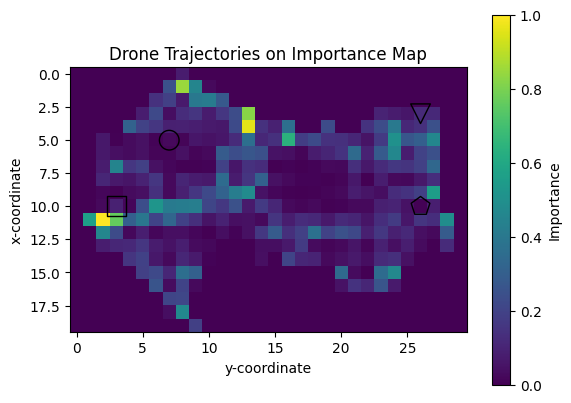

Time | ep_step:  1 1
Time | ep_step:  2 2
Time | ep_step:  3 3
Time | ep_step:  4 4
-----------
Episode:  1
Time | ep_step:  5 0
Time | ep_step:  6 1
Time | ep_step:  7 2
Time | ep_step:  8 3
Time | ep_step:  9 4
-----------
Episode:  2
Time | ep_step:  10 0


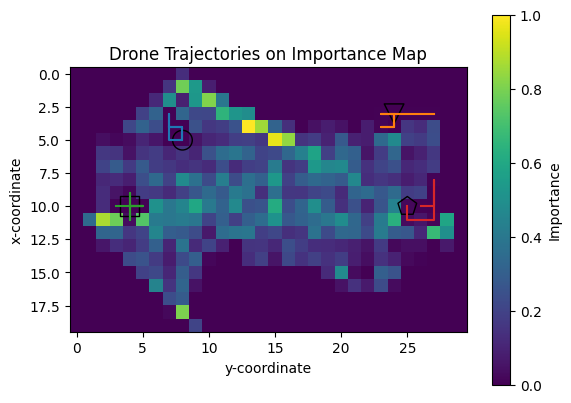

Time | ep_step:  11 1
Time | ep_step:  12 2
Time | ep_step:  13 3
Time | ep_step:  14 4
-----------
Episode:  3
Time | ep_step:  15 0
Time | ep_step:  16 1
Time | ep_step:  17 2
Time | ep_step:  18 3
Time | ep_step:  19 4
-----------
Episode:  4
Time | ep_step:  20 0


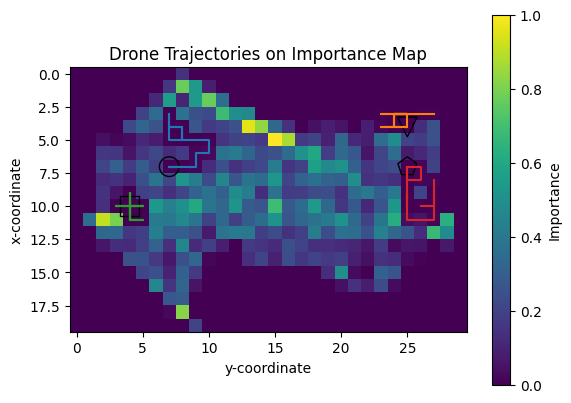

Time | ep_step:  21 1
Time | ep_step:  22 2
Time | ep_step:  23 3
Time | ep_step:  24 4
-----------
Episode:  5
Time | ep_step:  25 0
Time | ep_step:  26 1
Time | ep_step:  27 2
Time | ep_step:  28 3
Time | ep_step:  29 4
-----------
Episode:  6
Time | ep_step:  30 0


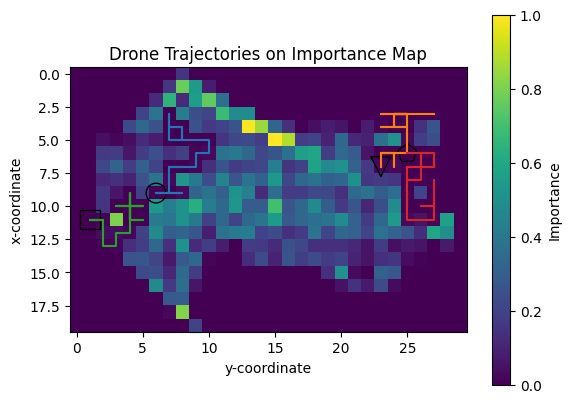

Time | ep_step:  31 1
Time | ep_step:  32 2
Time | ep_step:  33 3
Time | ep_step:  34 4
-----------
Episode:  7
Time | ep_step:  35 0
Time | ep_step:  36 1
Time | ep_step:  37 2
Time | ep_step:  38 3
Time | ep_step:  39 4
-----------
Episode:  8
Time | ep_step:  40 0


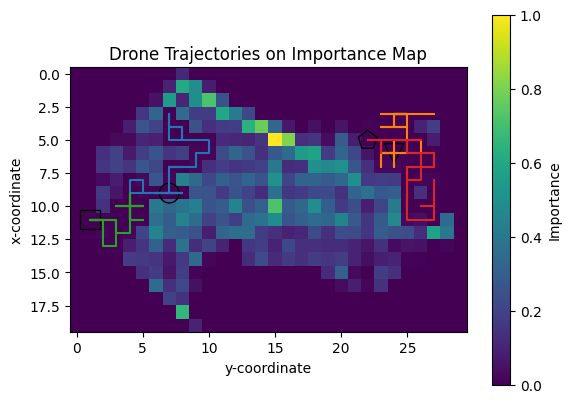

Time | ep_step:  41 1
Time | ep_step:  42 2
Time | ep_step:  43 3
Time | ep_step:  44 4
-----------
Episode:  9
Time | ep_step:  45 0
Time | ep_step:  46 1
Time | ep_step:  47 2
Time | ep_step:  48 3
Time | ep_step:  49 4
-----------
Episode:  10
Time | ep_step:  50 0


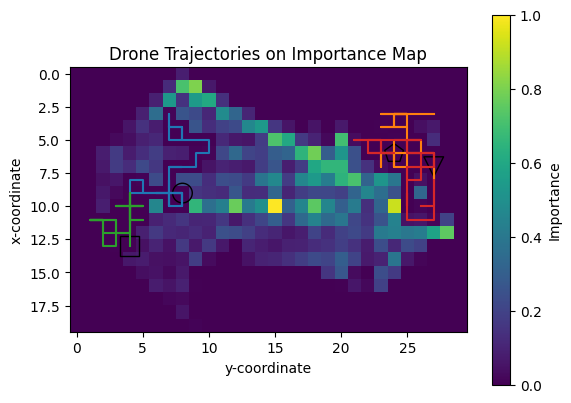

Time | ep_step:  51 1
Time | ep_step:  52 2
Time | ep_step:  53 3
Time | ep_step:  54 4
-----------
Episode:  11
Time | ep_step:  55 0
Time | ep_step:  56 1
Time | ep_step:  57 2
Time | ep_step:  58 3
Time | ep_step:  59 4
-----------
Episode:  12
Time | ep_step:  60 0


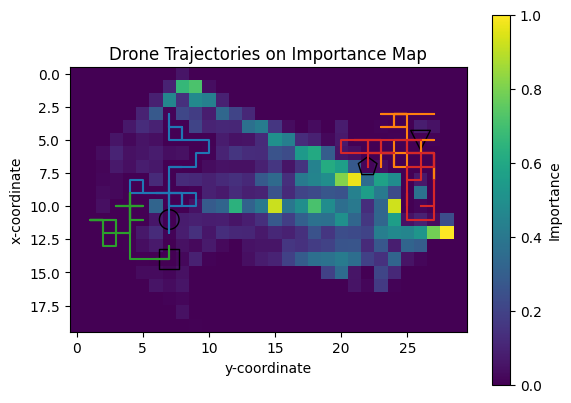

Time | ep_step:  61 1
Time | ep_step:  62 2
Time | ep_step:  63 3
Time | ep_step:  64 4
-----------
Episode:  13
Time | ep_step:  65 0
Time | ep_step:  66 1
Time | ep_step:  67 2
Time | ep_step:  68 3
Time | ep_step:  69 4
-----------
Episode:  14
Time | ep_step:  70 0


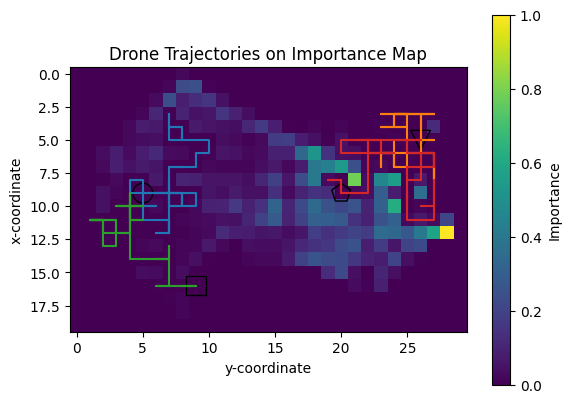

Time | ep_step:  71 1
Time | ep_step:  72 2
Time | ep_step:  73 3
Time | ep_step:  74 4
-----------
Episode:  15
Time | ep_step:  75 0
Time | ep_step:  76 1
Time | ep_step:  77 2
Time | ep_step:  78 3
Time | ep_step:  79 4
-----------
Episode:  16
Time | ep_step:  80 0


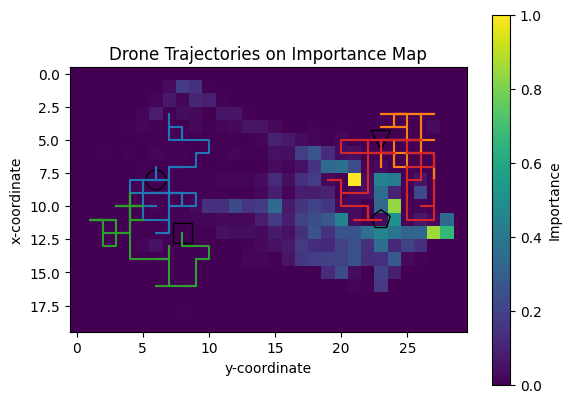

Time | ep_step:  81 1
Time | ep_step:  82 2
Time | ep_step:  83 3
Time | ep_step:  84 4
-----------
Episode:  17
Time | ep_step:  85 0
Time | ep_step:  86 1
Time | ep_step:  87 2
Time | ep_step:  88 3
Time | ep_step:  89 4
-----------
Episode:  18
Time | ep_step:  90 0


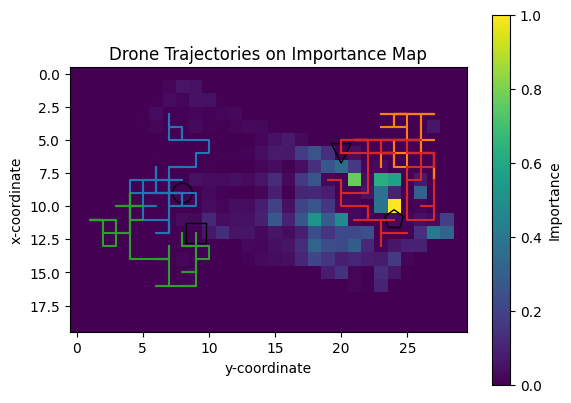

Time | ep_step:  91 1
Time | ep_step:  92 2
Time | ep_step:  93 3
Time | ep_step:  94 4
-----------
Episode:  19
Time | ep_step:  95 0
Time | ep_step:  96 1
Time | ep_step:  97 2
Time | ep_step:  98 3
Time | ep_step:  99 4
-----------
Episode:  20
Time | ep_step:  100 0


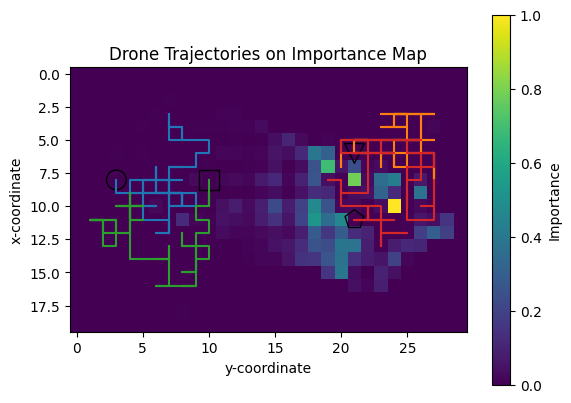

Time | ep_step:  101 1
Time | ep_step:  102 2
Time | ep_step:  103 3
Time | ep_step:  104 4
-----------
Episode:  21
Time | ep_step:  105 0
Time | ep_step:  106 1
Time | ep_step:  107 2
Time | ep_step:  108 3
Time | ep_step:  109 4
-----------
Episode:  22
Time | ep_step:  110 0


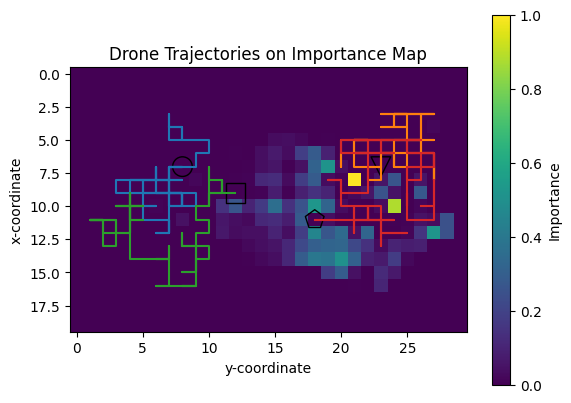

Time | ep_step:  111 1
Time | ep_step:  112 2
Time | ep_step:  113 3
Time | ep_step:  114 4
-----------
Episode:  23
Time | ep_step:  115 0
Time | ep_step:  116 1
Time | ep_step:  117 2
Time | ep_step:  118 3
Time | ep_step:  119 4
-----------
Episode:  24
Time | ep_step:  120 0


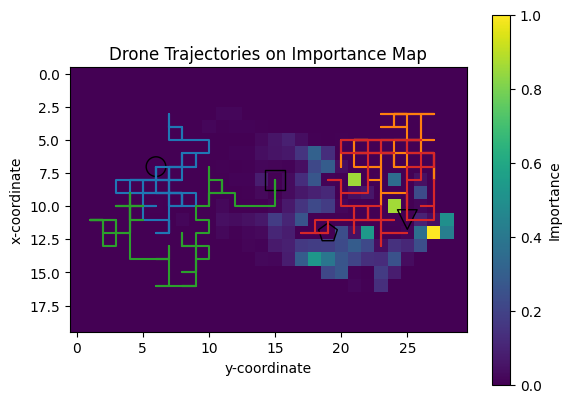

Time | ep_step:  121 1
Time | ep_step:  122 2
Time | ep_step:  123 3
Time | ep_step:  124 4
-----------
Episode:  25
Time | ep_step:  125 0
Time | ep_step:  126 1
Time | ep_step:  127 2
Time | ep_step:  128 3
Time | ep_step:  129 4
-----------


In [9]:
# Set mode: random, greedy, gru
mode = 'random'

pretrained_folder = r'\GRU_13_2_20000iter REAL all files good traj.pth' # r'\GRU_128_3_10000iter.pth'

run(link, df_link, ['000'], id = 'pred_vdist', mode = mode, load = True, pretrained_folder=pretrained_folder)